# Acne Classification Using CNN
## Goal:
Build a deep learning model to classify acne types using a CNN model, while addressing dataset imbalance through oversampling and augmentation.

## ----------------------------
## 1. IMPORTS
## ----------------------------

In [1]:

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, Rescaling
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

I0000 00:00:1777273421.807683    5709 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777273421.812605    5709 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777273422.218439    5709 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777273424.040844    5709 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

## 📦 2. Download Dataset

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tiswan14/acne-dataset-image")

print("Path to dataset files:", path)

/home/pratama/dev-python/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/pratama/.cache/kagglehub/datasets/tiswan14/acne-dataset-image/versions/1


## 📂 3. Dataset Paths & Parameters

In [3]:
base_dir = r"/home/pratama/.cache/kagglehub/datasets/tiswan14/acne-dataset-image/versions/1/AcneDataset"
train_dir = os.path.join(base_dir, "train")
valid_dir = os.path.join(base_dir, "valid")
test_dir  = os.path.join(base_dir, "test")

## 🧠 4. Load Datasets

In [4]:

# ----------------------------
# PARAMETERS
# ----------------------------
# Jumlah berapa kali belajar (32 kali)
BATCH_SIZE = 50
# Original image size
# Resize semua gambar
IMAGE_SIZE = 128
# Adjustment image size
# IMAGE_SIZE = 60

# ----------------------------
# LOAD DATASETS
# ----------------------------
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, label_mode='int', image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE, shuffle=True
)

valid_ds = tf.keras.preprocessing.image_dataset_from_directory(
    valid_dir, label_mode='int', image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE, shuffle=False
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir, label_mode='int', image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE, shuffle=False
)

class_names = train_ds.class_names
print("Classes:", class_names)
import json
# export classname
with open("class_names.json", "w") as f:
    json.dump(class_names, f)

Found 2918 files belonging to 8 classes.
Found 951 files belonging to 8 classes.
Found 948 files belonging to 8 classes.
Classes: ['Barier', 'Berminyak', 'Blackheads', 'Bopeng', 'Cyst', 'Papules', 'Pustules', 'Whiteheads']


E0000 00:00:1777273426.686016    5709 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 🖼️ 5. Visualize Sample Images



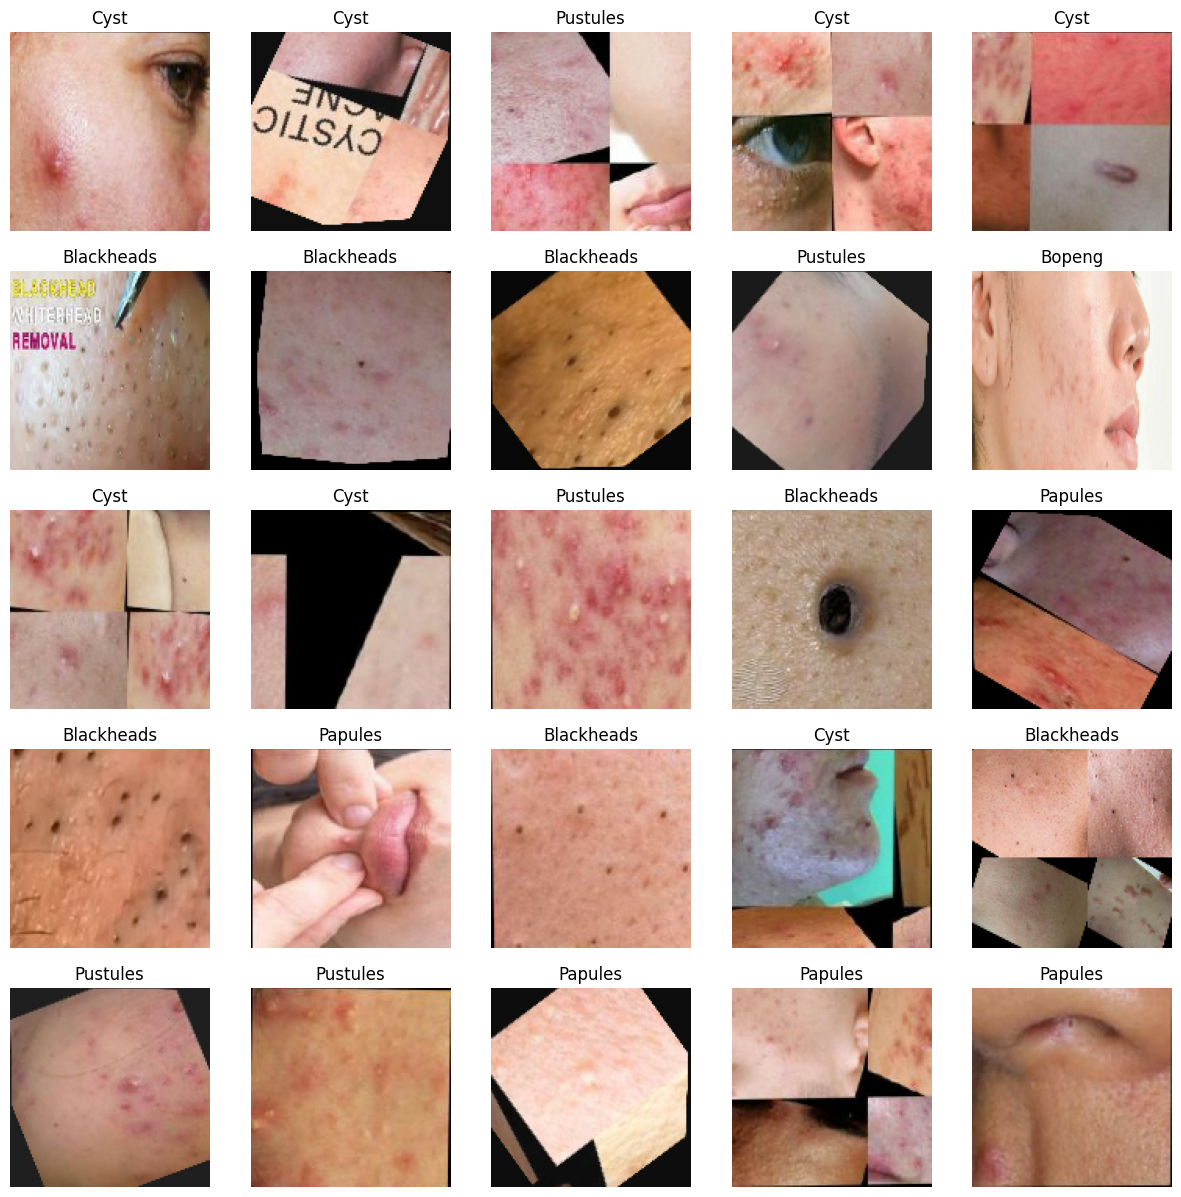

In [5]:
for image, label in train_ds.take(1):
    plt.figure(figsize=(15, 15))
    for i in range(25):  # dari 9 jadi 25
        ax = plt.subplot(5, 5, i + 1)
        plt.imshow(image[i].numpy().astype("uint8"))

        label_index = label[i].numpy()
        plt.title(class_names[label_index])
        plt.axis("off")

## 📊 6. Class Distribution

In [6]:
for folder in ['train', 'valid', 'test']:
    folder_path = os.path.join(base_dir, folder)
    for cls in os.listdir(folder_path):
        cls_path = os.path.join(folder_path, cls)
        if os.path.isdir(cls_path):  # Only count directories
            print(f"{folder}/{cls}:", len(os.listdir(cls_path)))

train/Berminyak: 40
train/Cyst: 645
train/Pustules: 584
train/Blackheads: 735
train/Whiteheads: 193
train/Bopeng: 70
train/Papules: 621
train/Barier: 30
valid/Berminyak: 10
valid/Cyst: 206
valid/Pustules: 217
valid/Blackheads: 240
valid/Whiteheads: 49
valid/Bopeng: 10
valid/Papules: 209
valid/Barier: 10
test/Berminyak: 10
test/Cyst: 189
test/Pustules: 205
test/Blackheads: 265
test/Whiteheads: 57
test/Bopeng: 10
test/Papules: 202
test/Barier: 10


### 📌 Observation:
Whiteheads (193 images) are underrepresented, which can bias the model.
We'll fix this using oversampling and augmentation.

## ⚖️ 7. Compute Class Weights

In [7]:
counts = [30, 40, 735, 70, 645, 621, 584, 193]
classes = np.arange(8)
y = np.repeat(classes, counts)
class_weight_dict = dict(zip(classes, compute_class_weight('balanced', classes=classes, y=y)))
print("Class weights:", class_weight_dict)



Class weights: {np.int64(0): np.float64(12.158333333333333), np.int64(1): np.float64(9.11875), np.int64(2): np.float64(0.4962585034013605), np.int64(3): np.float64(5.210714285714285), np.int64(4): np.float64(0.5655038759689922), np.int64(5): np.float64(0.5873590982286635), np.int64(6): np.float64(0.6245719178082192), np.int64(7): np.float64(1.8898963730569949)}


## 🔧 8. Preprocessing & Normalization

In [8]:
normalization_layer = Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
valid_ds = valid_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))


## 🔁 9. Data Augmentation

In [9]:
data_augmentation = Sequential([
    RandomFlip("horizontal_and_vertical"),
    RandomRotation(0.15),
    RandomZoom(0.15)
])


## 🔄 10. Oversampling Minority Class (Whiteheads)

In [10]:
# Unbatch the dataset
train_ds_unbatched = train_ds.unbatch()

# Split dataset by class
class_datasets = []
for i in range(len(class_names)):
    class_datasets.append(train_ds_unbatched.filter(lambda x, y: y==i))

# Oversample all minority classes to match target_count
target_count = max(counts)
for i in range(len(class_names)):
    if counts[i] < target_count:
        repeat_times = target_count // counts[i]
        remainder = target_count % counts[i]
        oversampled_class = class_datasets[i].repeat(repeat_times)
        oversampled_class = oversampled_class.concatenate(class_datasets[i].take(remainder))
        class_datasets[i] = oversampled_class
# Combine all classes
balanced_ds = class_datasets[0]
for ds in class_datasets[1:]:
    balanced_ds = balanced_ds.concatenate(ds)

# Shuffle, augment, and batch correctly
balanced_ds = balanced_ds.shuffle(5000)
balanced_ds = balanced_ds.map(lambda x, y: (data_augmentation(x, training=True), y))
balanced_ds = balanced_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

### ✅ Result: 
The dataset is now balanced across all acne types.

In [11]:
valid_ds = valid_ds.cache().prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.cache().prefetch(tf.data.AUTOTUNE)

## 🧰 11. Build CNN Model

In [12]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMAGE_SIZE, IMAGE_SIZE,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.5),
    Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 668,232 (2.55 MB)

 Trainable params: 668,232 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

## 🏋️‍♂️ 12. Train Model


In [ ]:
# ----------------------------
# CALLBACKS
# ----------------------------
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

# ----------------------------
# TRAIN MODEL
# ----------------------------
history = model.fit(
    balanced_ds,
    validation_data=valid_ds,
    epochs=100,
    # epochs=10,
    class_weight=class_weight_dict,
    callbacks=[early_stop, lr_scheduler],
    verbose=2
)
model.save("model/acne_model.keras")


Epoch 1/60


I0000 00:00:1777273440.107461    5902 shuffle_dataset_op.cc:453] ShuffleDatasetV3:61: Filling up shuffle buffer (this may take a while): 204 of 5000
I0000 00:00:1777273450.117810    5902 shuffle_dataset_op.cc:453] ShuffleDatasetV3:61: Filling up shuffle buffer (this may take a while): 406 of 5000
I0000 00:00:1777273460.147755    5902 shuffle_dataset_op.cc:453] ShuffleDatasetV3:61: Filling up shuffle buffer (this may take a while): 625 of 5000
W0000 00:00:1777273465.167056    5905 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9830600 bytes after encountering the first element of size 9830600 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
W0000 00:00:1777273466.033076    5904 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9830600 bytes after encountering the first element of size 9830600 bytes.This already causes the autotune ram budget to be exceeded. 

118/118 - 148s - 1s/step - accuracy: 0.1893 - loss: 5.6779 - val_accuracy: 0.0799 - val_loss: 3.0156 - learning_rate: 0.0010
Epoch 2/60


I0000 00:00:1777273586.448854    6067 shuffle_dataset_op.cc:453] ShuffleDatasetV3:61: Filling up shuffle buffer (this may take a while): 199 of 5000
I0000 00:00:1777273596.524624    6067 shuffle_dataset_op.cc:453] ShuffleDatasetV3:61: Filling up shuffle buffer (this may take a while): 403 of 5000
W0000 00:00:1777273609.376249    6069 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9830600 bytes after encountering the first element of size 9830600 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
W0000 00:00:1777273610.988850    6068 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9830600 bytes after encountering the first element of size 9830600 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
W0000 00:00:1777273612.575516    6069 prefetch_autotuner.cc:55] 

118/118 - 147s - 1s/step - accuracy: 0.3204 - loss: 4.1556 - val_accuracy: 0.1377 - val_loss: 3.6821 - learning_rate: 0.0010
Epoch 3/60


...

I0000 00:00:1777275605.809277    8104 shuffle_dataset_op.cc:453] ShuffleDatasetV3:61: Filling up shuffle buffer (this may take a while): 195 of 5000
W0000 00:00:1777275620.006898    8106 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9830600 bytes after encountering the first element of size 9830600 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
W0000 00:00:1777275621.639174    8105 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9830600 bytes after encountering the first element of size 9830600 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
W0000 00:00:1777275623.283925    8106 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9830600 bytes after encountering the first element of size 9830600 bytes.This already causes the autotune ram bu

118/118 - 149s - 1s/step - accuracy: 0.5889 - loss: 0.9637 - val_accuracy: 0.2681 - val_loss: 2.2912 - learning_rate: 2.5000e-04
Epoch 16/60


W0000 00:00:1777275747.485265    8211 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9830600 bytes after encountering the first element of size 9830600 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
W0000 00:00:1777275749.095481    8209 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9830600 bytes after encountering the first element of size 9830600 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
W0000 00:00:1777275750.623484    8211 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9830600 bytes after encountering the first element of size 9830600 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
W0000 00:00:1777275752.370151    8209 prefe

118/118 - 149s - 1s/step - accuracy: 0.6136 - loss: 0.8589 - val_accuracy: 0.2787 - val_loss: 2.1770 - learning_rate: 2.5000e-04
Epoch 17/60


W0000 00:00:1777275899.359152    8322 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9830600 bytes after encountering the first element of size 9830600 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
W0000 00:00:1777275900.963682    8321 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9830600 bytes after encountering the first element of size 9830600 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
W0000 00:00:1777275902.533152    8322 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9830600 bytes after encountering the first element of size 9830600 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
I0000 00:00:1777275903.437690    8320 shuff

## 📈 13. Evaluate Model

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 165ms/step - accuracy: 0.6743 - loss: 0.9208
Test Accuracy: 0.6742919683456421


## 🔍 14. Confusion Matrix & Classification Report

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get true and predicted labels for test set
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


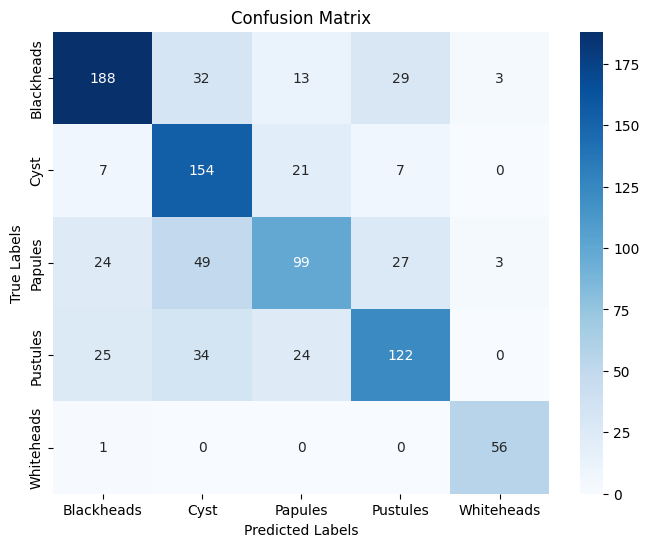

In [ ]:
# ----------------------------
# CONFUSION MATRIX
# ----------------------------
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()



In [ ]:
# ----------------------------
# CLASSIFICATION REPORT
# ----------------------------
report = classification_report(y_true, y_pred, target_names=class_names)
print("\nClassification Report:\n", report)



Classification Report:
               precision    recall  f1-score   support

  Blackheads       0.77      0.71      0.74       265
        Cyst       0.57      0.81      0.67       189
     Papules       0.63      0.49      0.55       202
    Pustules       0.66      0.60      0.63       205
  Whiteheads       0.90      0.98      0.94        57

    accuracy                           0.67       918
   macro avg       0.71      0.72      0.71       918
weighted avg       0.68      0.67      0.67       918



## 📊 15. Accuracy and Loss Curves


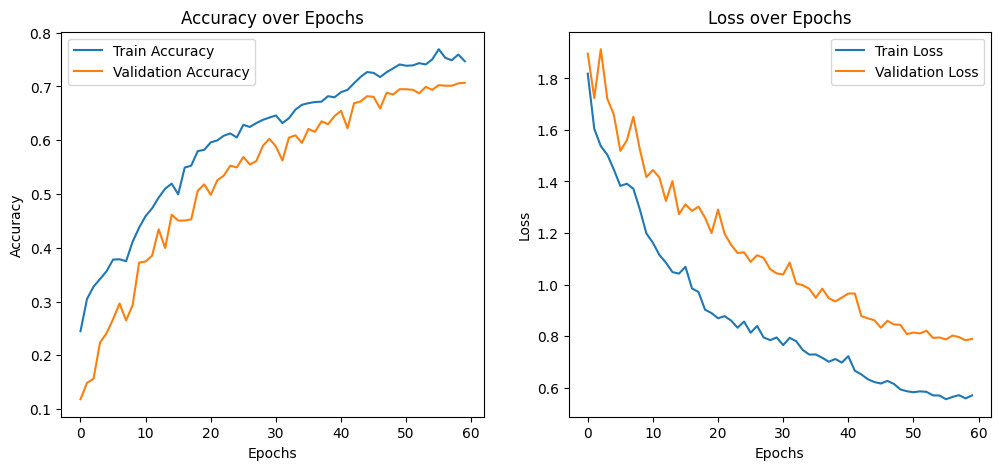

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()